<a href="https://colab.research.google.com/github/imdeepa99/pneumonia-anchor-free-detection/blob/main/notebooks/pneumonia_anchor_free_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Sun Sep 13 19:48:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/imdeepa99/pneumonia-anchor-free-detection.git

Cloning into 'pneumonia-anchor-free-detection'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 11 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 229.15 KiB | 14.32 MiB/s, done.


In [39]:
%cd /content/pneumonia-anchor-free-detection

[Errno 2] No such file or directory: '/content/pneumonia-anchor-free-detection'
/content


In [40]:
!mkdir -p data notebooks src results

In [41]:
!touch data/.gitkeep notebooks/.gitkeep src/.gitkeep results/.gitkeep

In [42]:
%cd hello

[Errno 2] No such file or directory: 'hello'
/content


In [ ]:
# 1. Setup Environment

In [8]:
from google.colab import files
import os

# Upload kaggle.json
uploaded = files.upload()

# Set up Kaggle credentials
os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle credentials ready!")

Saving kaggle.json to kaggle.json
Kaggle credentials ready!


In [2]:
!pip install pydicom kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.7 MB/s eta 0:00:00


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom

In [4]:
## 2. Kaggle Authentication


In [10]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [11]:
!kaggle competitions files -c rsna-pneumonia-detection-challenge

Next Page Token = CfDJ8OasvsPNS7VMiSwiBm2YVpMS5LLDR6WOk5TWKUFND8TFQJvLDcUHUrVDAXgZp4e2OjA4hCITvO7zn2TGKy5CxH2Yp9S8wnuRNt-vdWz4vCNnAVcxCjN57VPl57fB6IBxxihECyQqkagKc_L0eAwOn7OSxg4PqxMUFek-s-ElVgxwrn3E1cKCCwRFFDLUC3r_VKoRdeY
name                                                                size  creationDate                
------------------------------------------------------------  ----------  --------------------------  
GCP Credits Request Link - RSNA.txt                                   55  2019-12-11 23:45:26.544000  
stage_2_detailed_class_info.csv                                  1647396  2019-12-11 23:45:26.534000  
stage_2_sample_submission.csv                                     159027  2019-12-11 23:45:26.501000  
stage_2_test_images/0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm      125100  2019-12-11 23:45:39.760000  
stage_2_test_images/0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm      159200  2019-12-11 23:45:36.725000  
stage_2_test_images/000686d7-f4fc-448d-97a0-44fa9c5d3aa6.

In [43]:
!mkdir -p data

In [12]:
#new
!mkdir -p data

!kaggle competitions download \
-c rsna-pneumonia-detection-challenge \
-p data

100% 3.66G/3.66G [00:42<00:00, 93.6MB/s]



In [13]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p data

rsna-pneumonia-detection-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [14]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p data

rsna-pneumonia-detection-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [44]:
!kaggle competitions download \
-c rsna-pneumonia-detection-challenge \
-f stage_2_train_labels.csv \
-p data

stage_2_train_labels.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [45]:
!kaggle competitions download \
-c rsna-pneumonia-detection-challenge \
-f stage_2_train_labels.csv \
-p data

stage_2_train_labels.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [46]:
!ls -lh data

total 3.7G
drwxr-xr-x 4 root root 4.0K Sep 14 18:15 rsna
-rw-r--r-- 1 root root 3.7G Dec 11  2019 rsna-pneumonia-detection-challenge.zip
-rw-r--r-- 1 root root 1.5M Dec 11  2019 stage_2_train_labels.csv
-rw-r--r-- 1 root root 664K Dec 11  2019 stage_2_train_labels.csv.zip


In [47]:
!unzip -o data/stage_2_train_labels.csv.zip -d data

Archive:  data/stage_2_train_labels.csv.zip
  inflating: data/stage_2_train_labels.csv  


In [48]:
import pandas as pd

labels = pd.read_csv("data/stage_2_train_labels.csv")

labels.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [49]:
!kaggle competitions download \
-c rsna-pneumonia-detection-challenge \
-p data

rsna-pneumonia-detection-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q data/rsna-pneumonia-detection-challenge.zip -d data/rsna

replace data/rsna/GCP Credits Request Link - RSNA.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
replace data/rsna/stage_2_detailed_class_info.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [51]:
!ls data/rsna

'GCP Credits Request Link - RSNA.txt'   stage_2_test_images
 stage_2_detailed_class_info.csv        stage_2_train_images
 stage_2_sample_submission.csv


In [52]:
!ls data/rsna/stage_2_train_images | head

0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm
000924cf-0f8d-42bd-9158-1af53881a557.dcm
000db696-cf54-4385-b10b-6b16fbb3f985.dcm
000fe35a-2649-43d4-b027-e67796d412e0.dcm
001031d9-f904-4a23-b3e5-2c088acd19c6.dcm
0010f549-b242-4e94-87a8-57d79de215fc.dcm
001916b8-3d30-4935-a5d1-8eaddb1646cd.dcm
0022073f-cec8-42ec-ab5f-bc2314649235.dcm
0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm
0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm


In [57]:
!unzip -q data/rsna-pneumonia-detection-challenge.zip -d data/rsna

replace data/rsna/GCP Credits Request Link - RSNA.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [54]:
!ls data/rsna

'GCP Credits Request Link - RSNA.txt'   stage_2_test_images
 stage_2_detailed_class_info.csv        stage_2_train_images
 stage_2_sample_submission.csv


In [26]:
!ls data/rsna/stage_2_train_images | head

0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm
000924cf-0f8d-42bd-9158-1af53881a557.dcm
000db696-cf54-4385-b10b-6b16fbb3f985.dcm
000fe35a-2649-43d4-b027-e67796d412e0.dcm
001031d9-f904-4a23-b3e5-2c088acd19c6.dcm
0010f549-b242-4e94-87a8-57d79de215fc.dcm
001916b8-3d30-4935-a5d1-8eaddb1646cd.dcm
0022073f-cec8-42ec-ab5f-bc2314649235.dcm
0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm
0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm


In [27]:
## 4. Visualize X-ray with Ground-Truth Bounding Box

In [29]:
!pip install pydicom

In [ ]:
import os
import pydicom
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load labels
labels = pd.read_csv("data/rsna/stage_2_train_labels.csv")

# Select the first pneumonia-positive annotation
positive = labels[labels["Target"] == 1].iloc[0]

positive

In [ ]:
patient_id = positive["patientId"]

image_path = f"data/rsna/stage_2_train_images/{patient_id}.dcm"

dicom = pydicom.dcmread(image_path)
image = dicom.pixel_array

print("Patient:", patient_id)
print("Image shape:", image.shape)

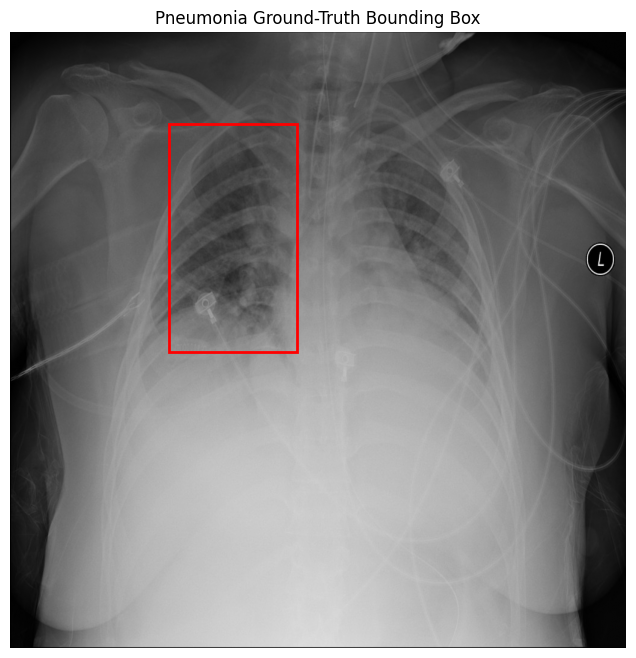

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image, cmap="gray")

x = positive["x"]
y = positive["y"]
width = positive["width"]
height = positive["height"]

box = patches.Rectangle(
    (x, y),
    width,
    height,
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(box)

ax.set_title("Pneumonia Ground-Truth Bounding Box")
ax.axis("off")

plt.show()

In [ ]:
## 5. Prepare Ground-Truth Annotations

In [26]:
!pwd
!ls

/content
data  kaggle.json  sample_data


In [ ]:
!find /content -name "stage_2_train_labels.csv" 2>/dev/null | head

/content/data/stage_2_train_labels.csv
/content/data/rsna/stage_2_train_labels.csv


In [27]:
import pandas as pd

labels = pd.read_csv("data/rsna/stage_2_train_labels.csv")

print("Labels loaded!")
print(labels.shape)

labels.head()

Labels loaded!
(30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [28]:
from collections import defaultdict

boxes_by_patient = defaultdict(list)

for row in labels.itertuples():

    if row.Target == 1:

        x1 = row.x
        y1 = row.y

        x2 = row.x + row.width
        y2 = row.y + row.height

        boxes_by_patient[row.patientId].append(
            [x1, y1, x2, y2]
        )

print("Patients with pneumonia boxes:",
      len(boxes_by_patient))

Patients with pneumonia boxes: 6012


In [29]:
box_counts = {
    patient_id: len(boxes)
    for patient_id, boxes in boxes_by_patient.items()
}

multiple_box_patients = {
    patient_id: count
    for patient_id, count in box_counts.items()
    if count > 1
}

print(
    "Patients with multiple pneumonia boxes:",
    len(multiple_box_patients)
)

# Show a few examples
list(multiple_box_patients.items())[:10]

Patients with multiple pneumonia boxes: 3398


[('00436515-870c-4b36-a041-de91049b9ab4', 2),
 ('00704310-78a8-4b38-8475-49f4573b2dbb', 2),
 ('00aecb01-a116-45a2-956c-08d2fa55433f', 2),
 ('00c0b293-48e7-4e16-ac76-9269ba535a62', 2),
 ('00f08de1-517e-4652-a04f-d1dc9ee48593', 2),
 ('010ccb9f-6d46-4380-af11-84f87397a1b8', 2),
 ('012a5620-d082-4bb8-9b3b-e72d8938000c', 2),
 ('0174c4bb-28f5-41e3-a13f-a396badc18bd', 2),
 ('019d950b-dd38-4cf3-a686-527a75728be6', 2),
 ('01a6eaa6-222f-4ea8-9874-bbd89dc1a1ce', 2)]

## 6. Patient-Level Train / Validation Split

We split the labeled RSNA patients into training and validation sets.

The split is performed at the patient level rather than the annotation-row level because
one patient can have multiple pneumonia bounding boxes. This prevents the same patient's
image from appearing in both training and validation data.

A stratified split is used to preserve a similar proportion of pneumonia-positive and
pneumonia-negative patients in both sets.

In [30]:
# ---------------------------------------------------------
# STEP 6: CREATE A PATIENT-LEVEL TRAIN / VALIDATION SPLIT
# ---------------------------------------------------------

# Import the function that will split our dataset
from sklearn.model_selection import train_test_split


# The labels CSV can contain multiple rows for one patient
# because one X-ray may contain multiple pneumonia boxes.
#
# Therefore, we first create ONE row per patient.
#
# max() means:
# If a patient has at least one Target = 1 annotation,
# that patient is considered pneumonia-positive.

patient_df = (
    labels
    .groupby("patientId")["Target"]
    .max()
    .reset_index()
)


# Display basic information before splitting
print("Total unique patients:", len(patient_df))
print("Pneumonia-positive patients:", patient_df["Target"].sum())
print("Pneumonia-negative patients:", (patient_df["Target"] == 0).sum())


# ---------------------------------------------------------
# Split patients into training and validation sets
# ---------------------------------------------------------
#
# test_size=0.20:
#     80% of patients → training
#     20% of patients → validation
#
# stratify:
#     keeps approximately the same positive/negative
#     distribution in both datasets
#
# random_state=42:
#     makes the split reproducible. If we run this cell
#     again, we get the same patient split.

train_df, val_df = train_test_split(
    patient_df,
    test_size=0.20,
    stratify=patient_df["Target"],
    random_state=42
)


# ---------------------------------------------------------
# Check the result
# ---------------------------------------------------------

print("\nTraining patients:", len(train_df))
print("Validation patients:", len(val_df))

print(
    "\nTraining pneumonia percentage:",
    round(train_df["Target"].mean() * 100, 2),
    "%"
)

print(
    "Validation pneumonia percentage:",
    round(val_df["Target"].mean() * 100, 2),
    "%"
)

Total unique patients: 26684
Pneumonia-positive patients: 6012
Pneumonia-negative patients: 20672

Training patients: 21347
Validation patients: 5337

Training pneumonia percentage: 22.53 %
Validation pneumonia percentage: 22.52 %


## 7. PyTorch Dataset Preparation

In this step, we create a custom PyTorch Dataset for the RSNA chest X-rays.

For each patient, the dataset will:
- locate the corresponding DICOM chest X-ray,
- read the image using pydicom,
- normalize the pixel values,
- resize the image for training,
- resize the ground-truth bounding-box coordinates accordingly,
- convert the image and bounding boxes into PyTorch tensors.

This prepares the RSNA data for the ResNet-50 backbone and the anchor-free detector.

In [31]:
# ---------------------------------------------------------
# STEP 7A: IMPORT LIBRARIES FOR DATASET PREPARATION
# ---------------------------------------------------------

# NumPy is used for numerical operations on the X-ray images.
import numpy as np

# PyTorch will be used to train our deep-learning detector.
import torch

# pydicom reads the .dcm medical image files in the RSNA dataset.
import pydicom

# Dataset is the PyTorch base class used to create our own
# custom RSNA dataset.
from torch.utils.data import Dataset

# This gives us image operations such as resizing.
import torchvision.transforms.functional as TF


# ---------------------------------------------------------
# PROJECT SETTINGS
# ---------------------------------------------------------

# Location of the RSNA training X-rays.
IMAGE_DIR = "data/rsna/stage_2_train_images"

# Original RSNA X-rays are large.
# For our Colab T4 implementation, we will initially resize
# them to 512 x 512 pixels to reduce GPU memory and training time.
#
# IMPORTANT:
# 512 x 512 is OUR practical reproduction choice.
# We should not claim that this value came from the paper.

IMAGE_SIZE = 512

print("Image directory:", IMAGE_DIR)
print("Training image size:", IMAGE_SIZE)

Image directory: data/rsna/stage_2_train_images
Training image size: 512


In [32]:
# ---------------------------------------------------------
# STEP 7B: TEST PREPROCESSING ON ONE PATIENT
# ---------------------------------------------------------

# Select the first patient from our training split.
sample_patient_id = train_df.iloc[0]["patientId"]

# Construct the path to that patient's DICOM X-ray.
sample_image_path = (
    f"{IMAGE_DIR}/{sample_patient_id}.dcm"
)

print("Patient ID:", sample_patient_id)
print("Image path:", sample_image_path)


# ---------------------------------------------------------
# READ THE DICOM X-RAY
# ---------------------------------------------------------

# pydicom reads the medical DICOM file.
dicom = pydicom.dcmread(sample_image_path)

# pixel_array extracts the actual X-ray image as a NumPy array.
image = dicom.pixel_array.astype(np.float32)

print("\nOriginal image shape:", image.shape)
print("Original minimum pixel value:", image.min())
print("Original maximum pixel value:", image.max())


# ---------------------------------------------------------
# NORMALIZE PIXEL VALUES
# ---------------------------------------------------------

# Convert the X-ray pixel values to approximately the range 0-1.
#
# Neural networks generally train more reliably when input
# values are on a controlled numerical scale.

image = (
    image - image.min()
) / (
    image.max() - image.min() + 1e-6
)

print("\nAfter normalization:")
print("Minimum:", image.min())
print("Maximum:", image.max())


# ---------------------------------------------------------
# CONVERT IMAGE TO A PYTORCH TENSOR
# ---------------------------------------------------------

# Current image shape:
# [height, width]
#
# unsqueeze(0) adds a channel dimension:
# [1, height, width]
#
# The 1 represents the single grayscale X-ray channel.

image_tensor = torch.from_numpy(image).unsqueeze(0)

print("\nTensor before resizing:", image_tensor.shape)


# ---------------------------------------------------------
# RESIZE TO 512 x 512
# ---------------------------------------------------------

image_tensor = TF.resize(
    image_tensor,
    [IMAGE_SIZE, IMAGE_SIZE],
    antialias=True
)

print("Tensor after resizing:", image_tensor.shape)

Patient ID: 960c2843-0cc6-43ef-bf6e-c84d33b8f4e2
Image path: data/rsna/stage_2_train_images/960c2843-0cc6-43ef-bf6e-c84d33b8f4e2.dcm

Original image shape: (1024, 1024)
Original minimum pixel value: 0.0
Original maximum pixel value: 216.0

After normalization:
Minimum: 0.0
Maximum: 1.0

Tensor before resizing: torch.Size([1, 1024, 1024])
Tensor after resizing: torch.Size([1, 512, 512])


## 8. Resize Ground-Truth Bounding Boxes

Because the original RSNA X-rays are 1024 × 1024 and we resize them to 512 × 512,
the bounding-box coordinates must also be scaled.

If the image dimensions are reduced by half, each x and y coordinate must also be reduced by half.

This keeps the pneumonia annotation aligned with the resized image.

In [33]:
# ---------------------------------------------------------
# STEP 8A: GET THE GROUND-TRUTH BOXES FOR THIS PATIENT
# ---------------------------------------------------------

# Retrieve all pneumonia boxes for the sample patient.
#
# If this patient has no pneumonia annotation,
# boxes_by_patient.get(...) returns an empty list.

sample_boxes = boxes_by_patient.get(
    sample_patient_id,
    []
)

print("Original ground-truth boxes:")
print(sample_boxes)

Original ground-truth boxes:
[]


In [34]:
# ---------------------------------------------------------
# STEP 8B: RESIZE THE BOUNDING-BOX COORDINATES
# ---------------------------------------------------------

# Get the original image dimensions.
original_height, original_width = image.shape

# Calculate how much the image was resized.
#
# Example:
# original width = 1024
# new width      = 512
#
# scale_x = 512 / 1024 = 0.5

scale_x = IMAGE_SIZE / original_width
scale_y = IMAGE_SIZE / original_height

print("Scale X:", scale_x)
print("Scale Y:", scale_y)


# Create a new list to store the resized boxes.
resized_boxes = []


# Each box is currently:
# [x1, y1, x2, y2]

for x1, y1, x2, y2 in sample_boxes:

    resized_box = [
        x1 * scale_x,
        y1 * scale_y,
        x2 * scale_x,
        y2 * scale_y
    ]

    resized_boxes.append(resized_box)


print("\nOriginal boxes:")
print(sample_boxes)

print("\nResized boxes:")
print(resized_boxes)

Scale X: 0.5
Scale Y: 0.5

Original boxes:
[]

Resized boxes:
[]


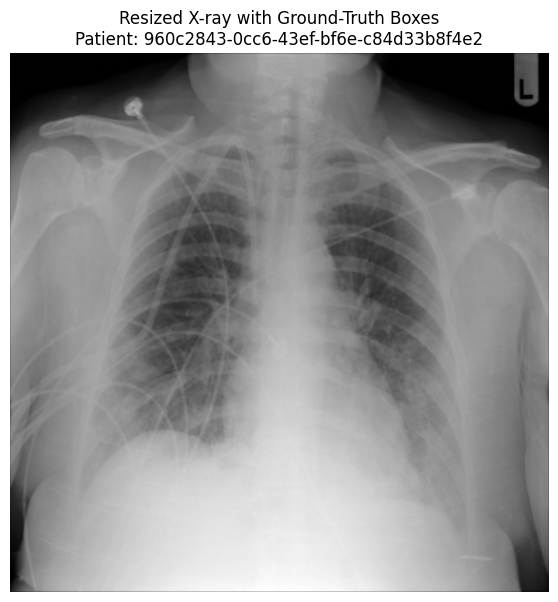

In [35]:
# ---------------------------------------------------------
# STEP 8C: VISUAL CHECK
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Use only the first channel for display because
# this X-ray is grayscale.
display_image = image_tensor[0].numpy()

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    display_image,
    cmap="gray"
)


# Draw every resized ground-truth box.
for box in resized_boxes:

    x1, y1, x2, y2 = box

    rectangle = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rectangle)


ax.set_title(
    f"Resized X-ray with Ground-Truth Boxes\nPatient: {sample_patient_id}"
)

ax.axis("off")

plt.show()

In [36]:
# ---------------------------------------------------------
# OPTIONAL: SELECT A POSITIVE TRAINING PATIENT
# ---------------------------------------------------------

positive_train_df = train_df[
    train_df["Target"] == 1
]

sample_patient_id = positive_train_df.iloc[0]["patientId"]

print("Selected positive patient:")
print(sample_patient_id)

Selected positive patient:
d6406a7b-d4ce-4495-ac63-ccde4b062fa7


## 9. ResNet-50 Backbone

The paper uses ResNet-50 as the backbone network.

The backbone does not directly predict pneumonia boxes.
Its job is to extract increasingly high-level visual features from the chest X-ray.

Earlier layers capture simple features such as edges and textures,
while deeper layers capture more complex structures.

We will use intermediate ResNet-50 feature maps later to construct
the multi-scale feature pyramid required by the anchor-free detector.

In [37]:
# ---------------------------------------------------------
# STEP 9A: LOAD RESNET-50
# ---------------------------------------------------------

import torch
import torch.nn as nn
import torchvision.models as models


# Load a ResNet-50 model with ImageNet pretrained weights.
#
# Pretrained weights give the backbone useful visual features
# instead of starting completely from random weights.
resnet = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

print("ResNet-50 loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


ResNet-50 loaded successfully.


In [38]:
# ---------------------------------------------------------
# STEP 9B: REMOVE THE FINAL CLASSIFICATION PART
# ---------------------------------------------------------
#
# We keep the convolutional stages of ResNet-50.
#
# These stages generate feature maps at different depths.
# The deeper the stage, the smaller the spatial resolution
# but the richer the semantic information.

class ResNet50Backbone(nn.Module):

    def __init__(self):
        super().__init__()

        # Load pretrained ResNet-50
        base_model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        # Initial convolutional stem
        self.conv1 = base_model.conv1
        self.bn1 = base_model.bn1
        self.relu = base_model.relu
        self.maxpool = base_model.maxpool

        # ResNet stages
        self.layer1 = base_model.layer1
        self.layer2 = base_model.layer2
        self.layer3 = base_model.layer3
        self.layer4 = base_model.layer4


    def forward(self, x):

        # Initial image processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Stage 1
        c2 = self.layer1(x)

        # Stage 2
        c3 = self.layer2(c2)

        # Stage 3
        c4 = self.layer3(c3)

        # Stage 4
        c5 = self.layer4(c4)

        # Return multiple feature maps instead of a classification
        return c2, c3, c4, c5


backbone = ResNet50Backbone()

print("Custom ResNet-50 backbone created.")

Custom ResNet-50 backbone created.


In [39]:
# ---------------------------------------------------------
# STEP 9C: PREPARE ONE SAMPLE FOR RESNET-50
# ---------------------------------------------------------

# Our X-ray currently has shape:
# [1, 512, 512]
#
# ResNet-50 expects:
# [3, 512, 512]
#
# We repeat the grayscale channel three times.
sample_input = image_tensor.repeat(3, 1, 1)

# Add a batch dimension:
#
# [3, 512, 512]
# becomes
# [1, 3, 512, 512]
sample_input = sample_input.unsqueeze(0)

print("Input shape:", sample_input.shape)

Input shape: torch.Size([1, 3, 512, 512])


In [40]:
# ---------------------------------------------------------
# STEP 9D: EXTRACT MULTI-LEVEL RESNET FEATURES
# ---------------------------------------------------------

backbone.eval()

with torch.no_grad():

    c2, c3, c4, c5 = backbone(sample_input)


print("C2 shape:", c2.shape)
print("C3 shape:", c3.shape)
print("C4 shape:", c4.shape)
print("C5 shape:", c5.shape)

C2 shape: torch.Size([1, 256, 128, 128])
C3 shape: torch.Size([1, 512, 64, 64])
C4 shape: torch.Size([1, 1024, 32, 32])
C5 shape: torch.Size([1, 2048, 16, 16])


## 10. Multi-Scale Feature Pyramid

The paper uses a multi-level feature pyramid so the detector can handle pneumonia regions of different sizes.

ResNet-50 gives feature maps at different depths. These maps have different numbers of channels and different spatial resolutions.

In this step, we:
- take the deeper ResNet feature maps,
- use 1×1 convolutions to reduce them to the same number of channels,
- combine high-level semantic information with higher-resolution feature maps,
- create multiple feature levels for the anchor-free detection heads.

These feature levels will later be used to predict pneumonia centers and bounding-box scales.

In [41]:
# ---------------------------------------------------------
# STEP 10A: CREATE THE FEATURE PYRAMID NETWORK
# ---------------------------------------------------------

import torch.nn.functional as F


class FeaturePyramid(nn.Module):

    def __init__(self, out_channels=256):
        super().__init__()

        # -------------------------------------------------
        # LATERAL 1x1 CONVOLUTIONS
        # -------------------------------------------------
        #
        # ResNet outputs:
        #
        # C3 = 512 channels
        # C4 = 1024 channels
        # C5 = 2048 channels
        #
        # We convert them all to 256 channels so they can
        # be combined together.

        self.lateral_c3 = nn.Conv2d(
            512,
            out_channels,
            kernel_size=1
        )

        self.lateral_c4 = nn.Conv2d(
            1024,
            out_channels,
            kernel_size=1
        )

        self.lateral_c5 = nn.Conv2d(
            2048,
            out_channels,
            kernel_size=1
        )


        # -------------------------------------------------
        # 3x3 CONVOLUTIONS
        # -------------------------------------------------
        #
        # After combining feature maps, these convolutions
        # smooth the resulting pyramid features.

        self.output_p3 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.output_p4 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.output_p5 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )


        # -------------------------------------------------
        # EXTRA COARSER PYRAMID LEVELS
        # -------------------------------------------------
        #
        # These levels reduce the spatial resolution further.
        #
        # They are useful for detecting larger pneumonia
        # regions.

        self.p6 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.p7 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=2,
            padding=1
        )


    def forward(self, c3, c4, c5):

        # ---------------------------------------------
        # Start from the deepest feature map
        # ---------------------------------------------

        p5 = self.lateral_c5(c5)


        # ---------------------------------------------
        # Upsample P5 and combine with C4
        # ---------------------------------------------

        p5_up = F.interpolate(
            p5,
            size=c4.shape[-2:],
            mode="nearest"
        )

        p4 = (
            self.lateral_c4(c4)
            + p5_up
        )


        # ---------------------------------------------
        # Upsample P4 and combine with C3
        # ---------------------------------------------

        p4_up = F.interpolate(
            p4,
            size=c3.shape[-2:],
            mode="nearest"
        )

        p3 = (
            self.lateral_c3(c3)
            + p4_up
        )


        # ---------------------------------------------
        # Smooth each pyramid level
        # ---------------------------------------------

        p3 = self.output_p3(p3)

        p4 = self.output_p4(p4)

        p5 = self.output_p5(p5)


        # ---------------------------------------------
        # Create two additional lower-resolution levels
        # ---------------------------------------------

        p6 = self.p6(p5)

        p7 = self.p7(F.relu(p6))


        return p3, p4, p5, p6, p7

In [42]:
# ---------------------------------------------------------
# STEP 10B: INITIALIZE THE FEATURE PYRAMID
# ---------------------------------------------------------

fpn = FeaturePyramid(
    out_channels=256
)

print("Feature Pyramid created successfully.")

Feature Pyramid created successfully.


In [43]:
# ---------------------------------------------------------
# STEP 10C: PASS RESNET FEATURES THROUGH THE PYRAMID
# ---------------------------------------------------------

fpn.eval()

with torch.no_grad():

    p3, p4, p5, p6, p7 = fpn(
        c3,
        c4,
        c5
    )


print("P3 shape:", p3.shape)
print("P4 shape:", p4.shape)
print("P5 shape:", p5.shape)
print("P6 shape:", p6.shape)
print("P7 shape:", p7.shape)

P3 shape: torch.Size([1, 256, 64, 64])
P4 shape: torch.Size([1, 256, 32, 32])
P5 shape: torch.Size([1, 256, 16, 16])
P6 shape: torch.Size([1, 256, 8, 8])
P7 shape: torch.Size([1, 256, 4, 4])


## 11. Anchor-Free Detection Head

The anchor-free detector predicts pneumonia directly from each feature-pyramid location.

Two predictions are produced:

1. Center prediction:
   estimates whether a feature-map location corresponds to the center of a pneumonia region.

2. Scale prediction:
   estimates the width and height of the pneumonia bounding box.

Unlike anchor-based detectors, this model does not begin with predefined anchor boxes.

In [44]:
# ---------------------------------------------------------
# STEP 11A: CREATE THE ANCHOR-FREE DETECTION HEAD
# ---------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F


class AnchorFreeHead(nn.Module):

    def __init__(self, in_channels=256):
        super().__init__()

        # Shared 3x3 convolution used before prediction.
        self.shared_conv = nn.Conv2d(
            in_channels,
            256,
            kernel_size=3,
            padding=1
        )

        # -------------------------------------------------
        # CENTER PREDICTION
        # -------------------------------------------------
        #
        # One output channel.
        #
        # High value = likely pneumonia center.
        # Low value  = background.
        self.center_head = nn.Conv2d(
            256,
            1,
            kernel_size=1
        )

        # -------------------------------------------------
        # SCALE PREDICTION
        # -------------------------------------------------
        #
        # Two output channels:
        #
        # channel 0 = predicted width
        # channel 1 = predicted height
        self.scale_head = nn.Conv2d(
            256,
            2,
            kernel_size=1
        )


    def forward(self, feature):

        x = F.relu(
            self.shared_conv(feature)
        )

        # Raw logits.
        center_logits = self.center_head(x)

        # softplus guarantees positive predicted sizes.
        scale = F.softplus(
            self.scale_head(x)
        )

        return center_logits, scale

In [45]:
# ---------------------------------------------------------
# STEP 11B: INITIALIZE THE DETECTION HEAD
# ---------------------------------------------------------

detection_head = AnchorFreeHead(
    in_channels=256
)

print("Anchor-free center/scale head created.")

Anchor-free center/scale head created.


In [46]:
# ---------------------------------------------------------
# STEP 11C: TEST THE HEAD
# ---------------------------------------------------------

with torch.no_grad():

    center_test, scale_test = detection_head(p3)

print("Center prediction shape:", center_test.shape)
print("Scale prediction shape:", scale_test.shape)

Center prediction shape: torch.Size([1, 1, 64, 64])
Scale prediction shape: torch.Size([1, 2, 64, 64])


## 12. Complete Anchor-Free Detector

The complete model combines:

Chest X-ray
→ ResNet-50 backbone
→ five-level feature pyramid
→ center and scale prediction heads.

In [47]:
# ---------------------------------------------------------
# STEP 12: COMPLETE PAPER-STYLE DETECTOR
# ---------------------------------------------------------

class PneumoniaAnchorFreeDetector(nn.Module):

    def __init__(self):

        super().__init__()

        # Feature extractor
        self.backbone = ResNet50Backbone()

        # Multi-scale feature pyramid
        self.fpn = FeaturePyramid(
            out_channels=256
        )

        # Shared anchor-free prediction head
        self.head = AnchorFreeHead(
            in_channels=256
        )


    def forward(self, images):

        # ---------------------------------------------
        # ResNet feature extraction
        # ---------------------------------------------

        c2, c3, c4, c5 = self.backbone(images)

        # ---------------------------------------------
        # Multi-scale feature pyramid
        # ---------------------------------------------

        p3, p4, p5, p6, p7 = self.fpn(
            c3,
            c4,
            c5
        )

        pyramid_features = [
            p3,
            p4,
            p5,
            p6,
            p7
        ]

        outputs = []

        # Apply the same detection head
        # independently to every pyramid level.
        for feature in pyramid_features:

            center_logits, scale = self.head(
                feature
            )

            outputs.append({
                "center": center_logits,
                "scale": scale
            })

        return outputs

In [48]:
# ---------------------------------------------------------
# INITIALIZE MODEL
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = PneumoniaAnchorFreeDetector().to(device)

print("Device:", device)
print("Complete anchor-free detector created.")

Device: cuda
Complete anchor-free detector created.


In [49]:
# ---------------------------------------------------------
# STEP 13: FEATURE PYRAMID STRIDES
# ---------------------------------------------------------

PYRAMID_STRIDES = [
    8,     # P3
    16,    # P4
    32,    # P5
    64,    # P6
    128    # P7
]

print(PYRAMID_STRIDES)

[8, 16, 32, 64, 128]


## 14. Feature-Level Selection

Different pneumonia regions have different sizes.

Small regions should be assigned to high-resolution pyramid levels,
while larger regions should be assigned to coarser levels.

The paper uses feature-level selection. Because the exact implementation
thresholds are not fully specified, this reproduction uses explicit scale
ranges for the five pyramid levels.

In [50]:
# ---------------------------------------------------------
# STEP 14: CHOOSE PYRAMID LEVEL BASED ON BOX SIZE
# ---------------------------------------------------------
#
# IMPORTANT:
# These exact thresholds are OUR reproduction choice.
#
# They should not be reported as exact thresholds from
# the original paper.

def choose_pyramid_level(width, height):

    # Use the largest box dimension as the object size.
    size = max(width, height)

    if size < 64:
        return 0       # P3

    elif size < 128:
        return 1       # P4

    elif size < 256:
        return 2       # P5

    elif size < 384:
        return 3       # P6

    else:
        return 4       # P7

## 15. Generate Center and Scale Training Targets

For every ground-truth pneumonia box:

1. calculate its center,
2. assign it to one feature-pyramid level,
3. locate the corresponding feature-map cell,
4. mark that cell as a positive center,
5. store the box width and height as the scale target.

In [51]:
# ---------------------------------------------------------
# STEP 15: GENERATE TARGETS FOR ONE IMAGE
# ---------------------------------------------------------

def create_targets(
    boxes,
    image_size=512
):

    target_levels = []

    # Create empty targets for every pyramid level.
    for stride in PYRAMID_STRIDES:

        feature_size = image_size // stride

        # Center target:
        # 0 = background
        # 1 = pneumonia center
        center_target = torch.zeros(
            (1, feature_size, feature_size),
            dtype=torch.float32
        )

        # Width and height targets.
        scale_target = torch.zeros(
            (2, feature_size, feature_size),
            dtype=torch.float32
        )

        # Tells us which locations should contribute
        # to the scale regression loss.
        scale_mask = torch.zeros(
            (feature_size, feature_size),
            dtype=torch.bool
        )

        target_levels.append({
            "center": center_target,
            "scale": scale_target,
            "mask": scale_mask
        })


    # -----------------------------------------------------
    # PROCESS EACH GROUND-TRUTH BOX
    # -----------------------------------------------------

    for box in boxes:

        x1, y1, x2, y2 = box.tolist()

        width = x2 - x1
        height = y2 - y1

        # Center of the pneumonia box.
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        # Decide which pyramid level should learn this box.
        level = choose_pyramid_level(
            width,
            height
        )

        stride = PYRAMID_STRIDES[level]

        # Convert image coordinates into feature-map coordinates.
        fx = int(center_x / stride)
        fy = int(center_y / stride)

        feature_size = image_size // stride

        # Prevent coordinates from leaving the feature map.
        fx = min(
            max(fx, 0),
            feature_size - 1
        )

        fy = min(
            max(fy, 0),
            feature_size - 1
        )

        # Mark pneumonia center.
        target_levels[level]["center"][
            0,
            fy,
            fx
        ] = 1.0

        # Predict scale relative to the level's stride.
        target_levels[level]["scale"][
            0,
            fy,
            fx
        ] = width / stride

        target_levels[level]["scale"][
            1,
            fy,
            fx
        ] = height / stride

        target_levels[level]["mask"][
            fy,
            fx
        ] = True

    return target_levels

## 16. Focal Loss

Most locations in an X-ray are background.

Focal loss reduces the contribution of easy background examples
and gives relatively more importance to difficult positive examples.

In [52]:
# ---------------------------------------------------------
# STEP 16: BINARY FOCAL LOSS
# ---------------------------------------------------------

def focal_loss(
    logits,
    targets,
    alpha=0.25,
    gamma=2.0
):

    # Standard binary cross entropy,
    # calculated independently at each position.
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        reduction="none"
    )

    # Convert logits to probabilities.
    probability = torch.sigmoid(logits)

    # Probability assigned to the correct class.
    pt = (
        probability * targets
        +
        (1 - probability) * (1 - targets)
    )

    # Alpha balancing.
    alpha_factor = (
        alpha * targets
        +
        (1 - alpha) * (1 - targets)
    )

    # Focal weighting.
    focal_weight = (
        alpha_factor
        *
        (1 - pt).pow(gamma)
    )

    loss = focal_weight * bce

    return loss.mean()

# Version 2 – Corrected Anchor-Free Pneumonia Detector

The first training experiment produced almost zero confidence at the true
pneumonia center. Version 2 improves the center target, loss normalization,
sampling strategy, augmentation, and detection head.

## 17. Smooth L1 Bounding-Box Scale Loss

The scale branch predicts the width and height of a pneumonia region.

Smooth L1 loss measures the difference between the predicted
and ground-truth box scales while being less sensitive to large
errors than ordinary squared error.

In [ ]:
# ---------------------------------------------------------
# STEP 17: SCALE REGRESSION LOSS
# ---------------------------------------------------------

def scale_loss(
    predicted_scale,
    target_scale,
    mask
):

    # If this image has no positive pneumonia location
    # at this pyramid level, there is no regression loss.
    if mask.sum() == 0:

        return predicted_scale.sum() * 0.0


    # predicted_scale:
    # [2, H, W]

    # Select only the pneumonia-center locations.
    predicted_positive = predicted_scale[
        :,
        mask
    ]

    target_positive = target_scale[
        :,
        mask
    ]

    return F.smooth_l1_loss(
        predicted_positive,
        target_positive
    )

In [ ]:
# ---------------------------------------------------------
# STEP 18: COMBINE CENTER + SCALE LOSSES
# ---------------------------------------------------------

def compute_detection_loss(
    outputs,
    boxes_batch,
    image_size=512
):

    total_center_loss = 0.0
    total_scale_loss = 0.0

    batch_size = len(boxes_batch)

    for batch_index in range(batch_size):

        # Build ground-truth targets for this image
        targets = create_targets(
            boxes_batch[batch_index],
            image_size=image_size
        )

        for level in range(5):

            # Model predictions for this image/level
            center_pred = outputs[level]["center"][batch_index]
            scale_pred = outputs[level]["scale"][batch_index]

            # Corresponding ground-truth targets
            center_target = targets[level]["center"].to(
                center_pred.device
            )

            scale_target = targets[level]["scale"].to(
                scale_pred.device
            )

            mask = targets[level]["mask"].to(
                scale_pred.device
            )

            # Center prediction loss
            total_center_loss += focal_loss(
                center_pred,
                center_target
            )

            # Bounding-box scale loss
            total_scale_loss += scale_loss(
                scale_pred,
                scale_target,
                mask
            )

    # Average across batch and five pyramid levels
    divisor = batch_size * 5

    center_loss = total_center_loss / divisor
    box_loss = total_scale_loss / divisor

    total_loss = center_loss + box_loss

    return {
        "total": total_loss,
        "center": center_loss,
        "scale": box_loss
    }

print("compute_detection_loss is ready.")

compute_detection_loss is ready.


## 19. Final Training Dataset

The final Dataset reads DICOM images, normalizes them, resizes the image
and bounding boxes, converts grayscale images to three channels for
ResNet-50, and optionally applies horizontal flipping during training.

In [ ]:
# ---------------------------------------------------------
# STEP 19: FINAL PYTORCH DATASET
# ---------------------------------------------------------

import random
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF


class PneumoniaTrainingDataset(Dataset):

    def __init__(
        self,
        patient_ids,
        image_dir,
        boxes_by_patient,
        image_size=512,
        training=True
    ):

        self.patient_ids = list(patient_ids)
        self.image_dir = image_dir
        self.boxes_by_patient = boxes_by_patient
        self.image_size = image_size
        self.training = training


    def __len__(self):

        return len(self.patient_ids)


    def __getitem__(self, idx):

        patient_id = self.patient_ids[idx]

        path = (
            f"{self.image_dir}/"
            f"{patient_id}.dcm"
        )

        dicom = pydicom.dcmread(path)

        image = dicom.pixel_array.astype(
            np.float32
        )


        # ---------------------------------------------
        # Handle MONOCHROME1 DICOM if encountered.
        # ---------------------------------------------

        if getattr(
            dicom,
            "PhotometricInterpretation",
            ""
        ) == "MONOCHROME1":

            image = image.max() - image


        original_h, original_w = image.shape


        # ---------------------------------------------
        # Normalize to 0-1
        # ---------------------------------------------

        image = (
            image - image.min()
        ) / (
            image.max()
            - image.min()
            + 1e-6
        )


        image = torch.from_numpy(
            image
        ).unsqueeze(0)


        # Resize image.
        image = TF.resize(
            image,
            [
                self.image_size,
                self.image_size
            ],
            antialias=True
        )


        # ResNet expects three channels.
        image = image.repeat(
            3,
            1,
            1
        )


        # ---------------------------------------------
        # RESIZE BOUNDING BOXES
        # ---------------------------------------------

        scale_x = (
            self.image_size / original_w
        )

        scale_y = (
            self.image_size / original_h
        )


        original_boxes = (
            self.boxes_by_patient.get(
                patient_id,
                []
            )
        )


        resized_boxes = []

        for x1, y1, x2, y2 in original_boxes:

            resized_boxes.append([
                x1 * scale_x,
                y1 * scale_y,
                x2 * scale_x,
                y2 * scale_y
            ])


        boxes = torch.tensor(
            resized_boxes,
            dtype=torch.float32
        ).reshape(-1, 4)


        # ---------------------------------------------
        # HORIZONTAL FLIP AUGMENTATION
        # ---------------------------------------------

        if (
            self.training
            and random.random() < 0.5
        ):

            image = TF.hflip(image)

            if len(boxes) > 0:

                flipped = boxes.clone()

                flipped[:, 0] = (
                    self.image_size
                    - boxes[:, 2]
                )

                flipped[:, 2] = (
                    self.image_size
                    - boxes[:, 0]
                )

                boxes = flipped


        return {
            "image": image,
            "boxes": boxes,
            "patient_id": patient_id
        }

In [ ]:
# ---------------------------------------------------------
# STEP 20A: CREATE DATASETS
# ---------------------------------------------------------

train_dataset = PneumoniaTrainingDataset(
    train_df["patientId"],
    IMAGE_DIR,
    boxes_by_patient,
    image_size=IMAGE_SIZE,
    training=True
)


val_dataset = PneumoniaTrainingDataset(
    val_df["patientId"],
    IMAGE_DIR,
    boxes_by_patient,
    image_size=IMAGE_SIZE,
    training=False
)


print(
    "Training images:",
    len(train_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)

Training images: 21347
Validation images: 5337


In [ ]:
# ---------------------------------------------------------
# STEP 20B: CUSTOM COLLATE FUNCTION
# ---------------------------------------------------------

def detection_collate_fn(batch):

    images = torch.stack([
        item["image"]
        for item in batch
    ])

    boxes = [
        item["boxes"]
        for item in batch
    ]

    patient_ids = [
        item["patient_id"]
        for item in batch
    ]

    return images, boxes, patient_ids

In [ ]:
# ---------------------------------------------------------
# STEP 20C: CREATE DATALOADERS
# ---------------------------------------------------------

BATCH_SIZE = 1


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=detection_collate_fn
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=detection_collate_fn
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 21347
Validation batches: 5337


In [ ]:
# ---------------------------------------------------------
# STEP 21: CHECK ONE TRAINING BATCH
# ---------------------------------------------------------

images, boxes, patient_ids = next(
    iter(train_loader)
)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Patient:",
    patient_ids[0]
)

print(
    "Ground-truth boxes:",
    boxes[0]
)

Image batch shape: torch.Size([1, 3, 512, 512])
Patient: 90849bf6-c078-47c5-a407-1e3fe1d006e5
Ground-truth boxes: tensor([], size=(0, 4))


In [ ]:
# ---------------------------------------------------------
# STEP 22: TEST MODEL + LOSS
# ---------------------------------------------------------

model.train()

images = images.to(device)

outputs = model(images)

losses = compute_detection_loss(
    outputs,
    boxes,
    image_size=IMAGE_SIZE
)


print(
    "Total loss:",
    losses["total"].item()
)

print(
    "Center loss:",
    losses["center"].item()
)

print(
    "Scale loss:",
    losses["scale"].item()
)

Total loss: 0.14281238615512848
Center loss: 0.14281238615512848
Scale loss: 0.0


In [ ]:
# ---------------------------------------------------------
# STEP 22B: TEST LOSS ON A POSITIVE PATIENT
# ---------------------------------------------------------

# Find the first training sample that actually has
# at least one pneumonia bounding box.
for i in range(len(train_dataset)):

    sample = train_dataset[i]

    if len(sample["boxes"]) > 0:
        positive_sample = sample
        break


print("Positive patient ID:")
print(positive_sample["patient_id"])

print("\nGround-truth boxes:")
print(positive_sample["boxes"])

Positive patient ID:
d6406a7b-d4ce-4495-ac63-ccde4b062fa7

Ground-truth boxes:
tensor([[388.0000,  50.5000, 469.5000, 115.5000]])


In [ ]:
# ---------------------------------------------------------
# STEP 22C: RUN POSITIVE PATIENT THROUGH THE MODEL
# ---------------------------------------------------------

# Add batch dimension and move image to GPU
positive_image = (
    positive_sample["image"]
    .unsqueeze(0)
    .to(device)
)

# compute_detection_loss expects a list of box tensors
positive_boxes = [
    positive_sample["boxes"]
]


model.train()

# Forward pass
outputs = model(
    positive_image
)

# Calculate losses
losses = compute_detection_loss(
    outputs,
    positive_boxes,
    image_size=IMAGE_SIZE
)


print(
    "Total loss:",
    losses["total"].item()
)

print(
    "Center loss:",
    losses["center"].item()
)

print(
    "Scale loss:",
    losses["scale"].item()
)

Total loss: 0.8062524199485779
Center loss: 0.14322791993618011
Scale loss: 0.6630244851112366


In [ ]:
# ---------------------------------------------------------
# STEP 26A: CREATE SMALL TRAINING SUBSET
# ---------------------------------------------------------

from torch.utils.data import Subset, DataLoader

# Use only 200 samples first.
# This is just to make sure repeated training works.
small_train_dataset = Subset(
    train_dataset,
    range(200)
)

small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=detection_collate_fn
)

print("Small training samples:", len(small_train_dataset))
print("Small training batches:", len(small_train_loader))

Small training samples: 200
Small training batches: 200


In [ ]:
# ---------------------------------------------------------
# STEP 24: DEFINE THE TRAINING FUNCTION
# ---------------------------------------------------------

from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    device
):

    # Put model into training mode
    model.train()

    # Variables for tracking average losses
    total_loss_sum = 0.0
    center_loss_sum = 0.0
    scale_loss_sum = 0.0

    # Progress bar so we can see training progress
    progress = tqdm(
        loader,
        desc="Training"
    )

    # Go through the images one batch at a time
    for images, boxes, patient_ids in progress:

        # Move images to GPU
        images = images.to(device)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # -----------------------------
        # FORWARD PASS
        # -----------------------------
        outputs = model(images)

        # -----------------------------
        # CALCULATE LOSS
        # -----------------------------
        losses = compute_detection_loss(
            outputs,
            boxes,
            image_size=IMAGE_SIZE
        )

        loss = losses["total"]

        # -----------------------------
        # BACKPROPAGATION
        # -----------------------------
        loss.backward()

        # Update model weights
        optimizer.step()

        # -----------------------------
        # SAVE LOSS VALUES
        # -----------------------------
        total_loss_sum += losses["total"].item()
        center_loss_sum += losses["center"].item()
        scale_loss_sum += losses["scale"].item()

        # Show current loss in progress bar
        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    # Calculate average losses for the epoch
    number_batches = len(loader)

    return {
        "total": total_loss_sum / number_batches,
        "center": center_loss_sum / number_batches,
        "scale": scale_loss_sum / number_batches
    }


print("train_one_epoch function is ready!")

train_one_epoch function is ready!


In [ ]:
# ---------------------------------------------------------
# STEP 25: CREATE OPTIMIZER
# ---------------------------------------------------------

# The paper uses Adam with an initial
# learning rate of 0.001.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer ready!")

Optimizer ready!


In [ ]:
# ---------------------------------------------------------
# STEP 26B: RUN ONE SMALL TRAINING EPOCH
# ---------------------------------------------------------

test_losses = train_one_epoch(
    model,
    small_train_loader,
    optimizer,
    device
)

print("\nSmall training test completed.")

print(
    "Average total loss:",
    test_losses["total"]
)

print(
    "Average center loss:",
    test_losses["center"]
)

print(
    "Average scale loss:",
    test_losses["scale"]
)

Training:   0%|          | 0/200 [00:00<?, ?it/s]


Small training test completed.
Average total loss: 1.240560435990247
Average center loss: 0.666249684772684
Average scale loss: 0.5743107411265373


In [ ]:
# ---------------------------------------------------------
# STEP 26B: RUN ONE SMALL TRAINING EPOCH
# ---------------------------------------------------------

test_losses = train_one_epoch(
    model,
    small_train_loader,
    optimizer,
    device
)

print("\nSmall training test completed.")

print(
    "Average total loss:",
    test_losses["total"]
)

print(
    "Average center loss:",
    test_losses["center"]
)

print(
    "Average scale loss:",
    test_losses["scale"]
)

Training:   0%|          | 0/200 [00:00<?, ?it/s]


Small training test completed.
Average total loss: 6.31176607014476
Average center loss: 2.060724763835121
Average scale loss: 4.25104116693139


In [ ]:
# ---------------------------------------------------------
# STEP 27A: RESET MODEL FOR FINAL TRAINING
# ---------------------------------------------------------

# Create a completely fresh model.
model = PneumoniaAnchorFreeDetector().to(device)

# Paper setting:
# Adam optimizer with initial learning rate = 0.001
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Learning-rate scheduler.
#
# The paper reports reducing the learning rate by a
# factor of 10 every 100 cycles.
# We keep this as an explicit reproduction interpretation.
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=100,
    gamma=0.1
)

print("Fresh model created.")
print("Device:", device)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Fresh model created.
Device: cuda
Learning rate: 0.001


In [ ]:
# ---------------------------------------------------------
# STEP 27B: DEFINE VALIDATION FUNCTION
# ---------------------------------------------------------

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device
):
    # Evaluation mode
    model.eval()

    total_loss_sum = 0.0

    # Go through validation images
    for images, boxes, patient_ids in loader:

        images = images.to(device)

        # Forward pass only — no backpropagation
        outputs = model(images)

        losses = compute_detection_loss(
            outputs,
            boxes,
            image_size=IMAGE_SIZE
        )

        total_loss_sum += losses["total"].item()

    # Return average validation loss
    return total_loss_sum / len(loader)


print("Validation function ready!")

Validation function ready!


In [ ]:
# ---------------------------------------------------------
# STEP 27C: FINAL TRAINING - START WITH 3 EPOCHS
# ---------------------------------------------------------

NUM_EPOCHS = 3

history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")


for epoch in range(1, NUM_EPOCHS + 1):

    print(f"\n{'=' * 50}")
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")
    print(f"{'=' * 50}")

    # ---------------------------------------------
    # TRAIN
    # ---------------------------------------------
    train_losses = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    # ---------------------------------------------
    # VALIDATE
    # ---------------------------------------------
    print("Running validation...")

    val_loss = validate_one_epoch(
        model,
        val_loader,
        device
    )

    # Update learning-rate scheduler
    scheduler.step()

    # Save history
    history["train_loss"].append(
        train_losses["total"]
    )

    history["val_loss"].append(
        val_loss
    )

    # Display results
    print(
        f"Train loss: {train_losses['total']:.4f}"
    )

    print(
        f"Validation loss: {val_loss:.4f}"
    )

    # ---------------------------------------------
    # SAVE BEST MODEL
    # ---------------------------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/best_pneumonia_detector.pth"
        )

        print("Best model saved!")


print("\nTraining completed!")


EPOCH 1/3


Training:   0%|          | 0/21347 [00:00<?, ?it/s]

Running validation...
Train loss: 1.9758
Validation loss: 1.6072
Best model saved!

EPOCH 2/3


Training:   0%|          | 0/21347 [00:00<?, ?it/s]

Running validation...
Train loss: 1.1006
Validation loss: 3.0470

EPOCH 3/3


Training:   0%|          | 0/21347 [00:00<?, ?it/s]

Running validation...
Train loss: 1.9571
Validation loss: 0.6797
Best model saved!

Training completed!


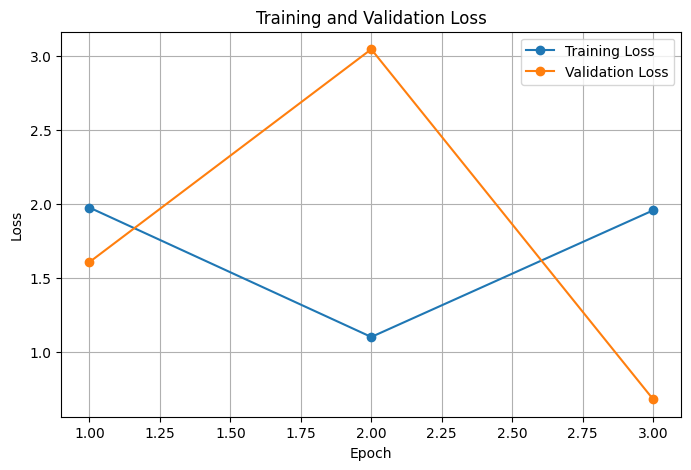

In [ ]:
# ---------------------------------------------------------
# STEP 28: PLOT TRAINING AND VALIDATION LOSS
# ---------------------------------------------------------

import matplotlib.pyplot as plt

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# ---------------------------------------------------------
# STEP 29: LOAD THE BEST MODEL
# ---------------------------------------------------------

model.load_state_dict(
    torch.load(
        "/content/best_pneumonia_detector.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [ ]:
# ---------------------------------------------------------
# STEP 30: DECODE MODEL PREDICTIONS INTO BOUNDING BOXES
# ---------------------------------------------------------

def decode_predictions(
    outputs,
    image_size=512,
    confidence_threshold=0.1
):

    all_boxes = []
    all_scores = []

    # Go through P3, P4, P5, P6 and P7
    for level, output in enumerate(outputs):

        stride = PYRAMID_STRIDES[level]

        # Convert center logits into probabilities
        center_scores = torch.sigmoid(
            output["center"][0, 0]
        )

        # Predicted width and height
        scales = output["scale"][0]

        # Find locations with confidence > threshold
        locations = torch.nonzero(
            center_scores > confidence_threshold
        )

        for location in locations:

            y, x = location.tolist()

            score = center_scores[y, x].item()

            # Convert feature-map location
            # back into image coordinates
            center_x = (x + 0.5) * stride
            center_y = (y + 0.5) * stride

            width = scales[0, y, x].item() * stride
            height = scales[1, y, x].item() * stride

            # Center + width/height
            # becomes [x1, y1, x2, y2]
            x1 = center_x - width / 2
            y1 = center_y - height / 2

            x2 = center_x + width / 2
            y2 = center_y + height / 2

            # Keep boxes inside the image
            x1 = max(0, x1)
            y1 = max(0, y1)

            x2 = min(image_size, x2)
            y2 = min(image_size, y2)

            all_boxes.append(
                [x1, y1, x2, y2]
            )

            all_scores.append(score)

    # Handle image with no predictions
    if len(all_boxes) == 0:

        return (
            torch.zeros((0, 4)),
            torch.zeros((0,))
        )

    return (
        torch.tensor(
            all_boxes,
            dtype=torch.float32
        ),
        torch.tensor(
            all_scores,
            dtype=torch.float32
        )
    )

print("Prediction decoder ready!")

Prediction decoder ready!


In [ ]:
# ---------------------------------------------------------
# STEP 31: NON-MAXIMUM SUPPRESSION
# ---------------------------------------------------------

from torchvision.ops import nms


def apply_nms(
    boxes,
    scores,
    threshold=0.5
):

    # Nothing to remove if there are no predictions
    if len(boxes) == 0:
        return boxes, scores

    keep = nms(
        boxes,
        scores,
        threshold
    )

    return (
        boxes[keep],
        scores[keep]
    )


print("NMS function ready!")

NMS function ready!


In [ ]:
# ---------------------------------------------------------
# STEP 32A: FIND ONE POSITIVE VALIDATION PATIENT
# ---------------------------------------------------------

for i in range(len(val_dataset)):

    sample = val_dataset[i]

    if len(sample["boxes"]) > 0:

        positive_val_index = i
        break


print(
    "Positive validation index:",
    positive_val_index
)

print(
    "Ground-truth boxes:",
    val_dataset[
        positive_val_index
    ]["boxes"]
)

Positive validation index: 2
Ground-truth boxes: tensor([[ 65.0000, 202.0000, 171.5000, 268.5000]])


In [ ]:
# ---------------------------------------------------------
# STEP 32B: VISUALIZE MODEL PREDICTION
# ---------------------------------------------------------

import matplotlib.patches as patches


@torch.no_grad()
def show_prediction(
    model,
    dataset,
    index
):

    model.eval()

    sample = dataset[index]

    image = sample["image"]
    gt_boxes = sample["boxes"]

    # Send one image through the trained model
    outputs = model(
        image
        .unsqueeze(0)
        .to(device)
    )

    # Convert model output to boxes
    pred_boxes, scores = decode_predictions(
        outputs,
        image_size=IMAGE_SIZE,
        confidence_threshold=0.1
    )

    # Remove duplicate overlapping boxes
    pred_boxes, scores = apply_nms(
        pred_boxes,
        scores,
        threshold=0.5
    )

    print(
        "Number of ground-truth boxes:",
        len(gt_boxes)
    )

    print(
        "Number of predicted boxes:",
        len(pred_boxes)
    )

    print(
        "Prediction scores:",
        scores
    )

    # Display chest X-ray
    fig, ax = plt.subplots(
        figsize=(8, 8)
    )

    ax.imshow(
        image[0].cpu(),
        cmap="gray"
    )

    # GREEN = radiologist ground truth
    for box in gt_boxes:

        x1, y1, x2, y2 = box.tolist()

        rectangle = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="green",
            facecolor="none"
        )

        ax.add_patch(rectangle)

    # RED = our model prediction
    for box, score in zip(
        pred_boxes,
        scores
    ):

        x1, y1, x2, y2 = box.tolist()

        rectangle = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rectangle)

        ax.text(
            x1,
            y1,
            f"{score:.2f}",
            fontsize=9
        )

    ax.set_title(
        "Green = Ground Truth | Red = Prediction"
    )

    ax.axis("off")

    plt.show()

Number of ground-truth boxes: 1
Number of predicted boxes: 0
Prediction scores: tensor([])


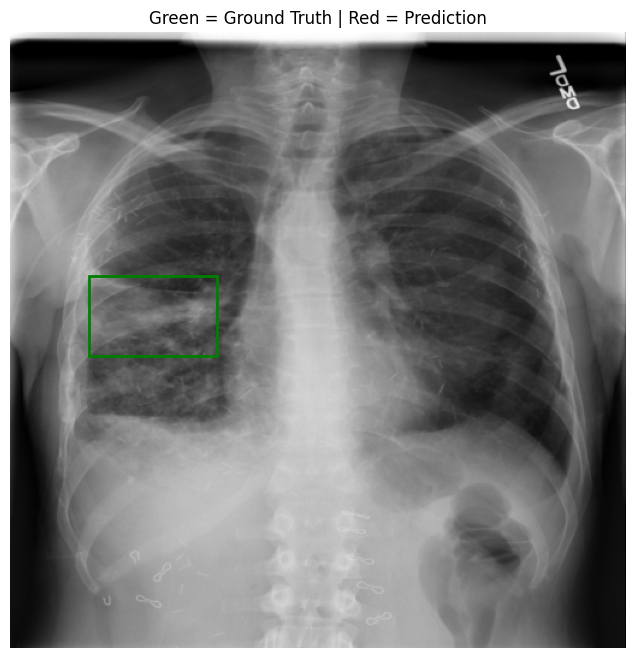

In [ ]:
# ---------------------------------------------------------
# STEP 32C: SHOW THE RESULT
# ---------------------------------------------------------

show_prediction(
    model,
    val_dataset,
    positive_val_index
)

In [ ]:
# ---------------------------------------------------------
# STEP 32D: CHECK RAW CENTER CONFIDENCE SCORES
# ---------------------------------------------------------

model.eval()

sample = val_dataset[positive_val_index]

image = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)

with torch.no_grad():
    outputs = model(image)


print("Maximum center confidence at each pyramid level:\n")

for level, output in enumerate(outputs):

    # Convert raw logits to probabilities
    probabilities = torch.sigmoid(
        output["center"][0, 0]
    )

    print(
        f"P{level + 3}:",
        f"{probabilities.max().item():.6f}"
    )

Maximum center confidence at each pyramid level:

P3: 0.000000
P4: 0.055603
P5: 0.000626
P6: 0.000000
P7: 0.055603


In [ ]:
# ---------------------------------------------------------
# STEP 32E: CHECK CONFIDENCE AT THE TRUE PNEUMONIA CENTER
# ---------------------------------------------------------

sample = val_dataset[positive_val_index]

gt_boxes = sample["boxes"]

print("Ground-truth boxes:")
print(gt_boxes)

# Use the first GT pneumonia box
x1, y1, x2, y2 = gt_boxes[0].tolist()

# Width and height
box_width = x2 - x1
box_height = y2 - y1

# Ground-truth center
gt_center_x = (x1 + x2) / 2
gt_center_y = (y1 + y2) / 2

# Which pyramid level should this box use?
assigned_level = choose_pyramid_level(
    box_width,
    box_height
)

stride = PYRAMID_STRIDES[assigned_level]

# Convert image center coordinates
# into feature-map coordinates
fx = int(gt_center_x / stride)
fy = int(gt_center_y / stride)

print("\nBox width:", box_width)
print("Box height:", box_height)

print("\nAssigned pyramid level:", f"P{assigned_level + 3}")
print("Stride:", stride)

print("\nGT center in image:")
print("x =", gt_center_x)
print("y =", gt_center_y)

print("\nGT center in feature map:")
print("x =", fx)
print("y =", fy)


# ---------------------------------------------------------
# GET MODEL CONFIDENCE AT THAT EXACT LOCATION
# ---------------------------------------------------------

image = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)

model.eval()

with torch.no_grad():

    outputs = model(image)

    center_probabilities = torch.sigmoid(
        outputs[assigned_level]["center"][0, 0]
    )

    true_center_score = center_probabilities[
        fy,
        fx
    ].item()

    maximum_score = center_probabilities.max().item()


print("\nConfidence at TRUE pneumonia center:")
print(true_center_score)

print("\nMaximum confidence on this pyramid level:")
print(maximum_score)

Ground-truth boxes:
tensor([[ 65.0000, 202.0000, 171.5000, 268.5000]])

Box width: 106.5
Box height: 66.5

Assigned pyramid level: P4
Stride: 16

GT center in image:
x = 118.25
y = 235.25

GT center in feature map:
x = 7
y = 14

Confidence at TRUE pneumonia center:
0.0

Maximum confidence on this pyramid level:
0.05560288578271866


# Version 2 – Corrected Anchor-Free Pneumonia Detector

The first training experiment produced almost zero confidence at the true
pneumonia center. Version 2 improves the center target, loss normalization,
sampling strategy, augmentation, and detection head.

In [53]:
# ============================================================
# VERSION 2 - IMPROVED ANCHOR-FREE DETECTOR
# ============================================================
#
# Improvements:
# 1. Separate center and scale branches.
# 2. Low prior probability for pneumonia-center prediction.
#
# This helps because true object-center locations are very rare
# compared with background locations.
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class AnchorFreeHead(nn.Module):

    def __init__(self, in_channels=256):
        super().__init__()

        # ----------------------------------------------------
        # CENTER BRANCH
        # Predicts WHERE the pneumonia center is.
        # ----------------------------------------------------
        self.center_conv = nn.Conv2d(
            in_channels,
            256,
            kernel_size=3,
            padding=1
        )

        self.center_output = nn.Conv2d(
            256,
            1,
            kernel_size=1
        )

        # ----------------------------------------------------
        # SCALE BRANCH
        # Predicts width + height of pneumonia bounding box.
        # ----------------------------------------------------
        self.scale_conv = nn.Conv2d(
            in_channels,
            256,
            kernel_size=3,
            padding=1
        )

        self.scale_output = nn.Conv2d(
            256,
            2,
            kernel_size=1
        )

        # Start center probability near 1%.
        prior_probability = 0.01

        bias_value = -math.log(
            (1 - prior_probability)
            / prior_probability
        )

        nn.init.constant_(
            self.center_output.bias,
            bias_value
        )


    def forward(self, feature):

        # Center prediction
        center_features = F.relu(
            self.center_conv(feature)
        )

        center_logits = self.center_output(
            center_features
        )

        # Width / height prediction
        scale_features = F.relu(
            self.scale_conv(feature)
        )

        scale = F.softplus(
            self.scale_output(scale_features)
        )

        return center_logits, scale


# ------------------------------------------------------------
# Rebuild complete detector using the NEW head.
# ------------------------------------------------------------

class PneumoniaAnchorFreeDetector(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = ResNet50Backbone()

        self.fpn = FeaturePyramid(
            out_channels=256
        )

        self.head = AnchorFreeHead(
            in_channels=256
        )


    def forward(self, images):

        c2, c3, c4, c5 = self.backbone(
            images
        )

        p3, p4, p5, p6, p7 = self.fpn(
            c3,
            c4,
            c5
        )

        pyramid_features = [
            p3,
            p4,
            p5,
            p6,
            p7
        ]

        outputs = []

        for feature in pyramid_features:

            center_logits, scale = self.head(
                feature
            )

            outputs.append({
                "center": center_logits,
                "scale": scale
            })

        return outputs


print("Version 2 detector ready.")

Version 2 detector ready.


In [54]:
# ============================================================
# VERSION 2 - GAUSSIAN CENTER TARGET
# ============================================================

import numpy as np


def gaussian_radius(
    box_h,
    box_w,
    min_overlap=0.7
):

    a1 = 1
    b1 = box_h + box_w

    c1 = (
        box_w * box_h
        * (1 - min_overlap)
        / (1 + min_overlap)
    )

    sq1 = math.sqrt(
        max(
            b1 ** 2 - 4 * a1 * c1,
            0
        )
    )

    r1 = (b1 + sq1) / 2


    a2 = 4
    b2 = 2 * (box_h + box_w)

    c2 = (
        (1 - min_overlap)
        * box_w
        * box_h
    )

    sq2 = math.sqrt(
        max(
            b2 ** 2 - 4 * a2 * c2,
            0
        )
    )

    r2 = (b2 + sq2) / 2


    a3 = 4 * min_overlap

    b3 = (
        -2
        * min_overlap
        * (box_h + box_w)
    )

    c3 = (
        (min_overlap - 1)
        * box_w
        * box_h
    )

    sq3 = math.sqrt(
        max(
            b3 ** 2 - 4 * a3 * c3,
            0
        )
    )

    r3 = (b3 + sq3) / 2


    return max(
        0,
        int(min(r1, r2, r3))
    )


def gaussian_2d(
    shape,
    sigma
):

    m, n = [
        (s - 1.) / 2.
        for s in shape
    ]

    y, x = np.ogrid[
        -m:m + 1,
        -n:n + 1
    ]

    gaussian = np.exp(
        -(x * x + y * y)
        /
        (2 * sigma * sigma)
    )

    return gaussian


def draw_gaussian(
    heatmap,
    center_x,
    center_y,
    radius
):

    diameter = (
        2 * radius + 1
    )

    gaussian = gaussian_2d(
        (diameter, diameter),
        sigma=diameter / 6
    )

    height, width = heatmap.shape

    x = int(center_x)
    y = int(center_y)

    left = min(x, radius)

    right = min(
        width - x,
        radius + 1
    )

    top = min(y, radius)

    bottom = min(
        height - y,
        radius + 1
    )


    heatmap_region = heatmap[
        y - top:y + bottom,
        x - left:x + right
    ]

    gaussian_region = gaussian[
        radius - top:radius + bottom,
        radius - left:radius + right
    ]


    if (
        heatmap_region.size > 0
        and gaussian_region.size > 0
    ):

        np.maximum(
            heatmap_region,
            gaussian_region,
            out=heatmap_region
        )


print("Gaussian helper functions ready.")

Gaussian helper functions ready.


In [55]:
# ============================================================
# VERSION 2 - TARGET GENERATION
# ============================================================

def create_targets_v2(
    boxes,
    image_size=512,
    min_radius=1
):

    target_levels = []


    # Create empty target for each FPN level.
    for stride in PYRAMID_STRIDES:

        feature_size = (
            image_size // stride
        )

        center_target = np.zeros(
            (
                feature_size,
                feature_size
            ),
            dtype=np.float32
        )

        scale_target = torch.zeros(
            (
                2,
                feature_size,
                feature_size
            ),
            dtype=torch.float32
        )

        scale_mask = torch.zeros(
            (
                feature_size,
                feature_size
            ),
            dtype=torch.bool
        )

        target_levels.append({
            "center_np": center_target,
            "scale": scale_target,
            "mask": scale_mask
        })


    # --------------------------------------------------------
    # Process all GT pneumonia boxes
    # --------------------------------------------------------

    for box in boxes:

        x1, y1, x2, y2 = (
            box.tolist()
        )

        width = x2 - x1
        height = y2 - y1

        if (
            width <= 0
            or height <= 0
        ):
            continue


        center_x = (
            x1 + x2
        ) / 2

        center_y = (
            y1 + y2
        ) / 2


        # Choose FPN level
        level = choose_pyramid_level(
            width,
            height
        )

        stride = PYRAMID_STRIDES[
            level
        ]

        feature_size = (
            image_size // stride
        )


        fx = int(
            center_x / stride
        )

        fy = int(
            center_y / stride
        )


        fx = min(
            max(fx, 0),
            feature_size - 1
        )

        fy = min(
            max(fy, 0),
            feature_size - 1
        )


        # Gaussian size based on box size
        radius = gaussian_radius(
            height / stride,
            width / stride
        )

        radius = max(
            min_radius,
            radius
        )


        draw_gaussian(
            target_levels[level]["center_np"],
            fx,
            fy,
            radius
        )


        # Width / height target at exact center
        target_levels[level]["scale"][
            0,
            fy,
            fx
        ] = width / stride


        target_levels[level]["scale"][
            1,
            fy,
            fx
        ] = height / stride


        target_levels[level]["mask"][
            fy,
            fx
        ] = True


    # Convert heatmap into tensor
    for target in target_levels:

        target["center"] = (
            torch.from_numpy(
                target.pop("center_np")
            )
            .unsqueeze(0)
        )


    return target_levels


print("Version 2 target generation ready.")

Version 2 target generation ready.


In [56]:
# ============================================================
# VERSION 2 - HEATMAP FOCAL LOSS
# ============================================================

def heatmap_focal_components(
    pred_logits,
    gt_heatmap,
    alpha=2.0,
    beta=4.0
):

    # Convert model logits to probabilities.
    pred = torch.sigmoid(
        pred_logits
    ).clamp(
        min=1e-4,
        max=1 - 1e-4
    )


    # Exact center = positive.
    pos_mask = (
        gt_heatmap == 1
    ).float()


    # Other positions = negative.
    neg_mask = (
        gt_heatmap < 1
    ).float()


    # Pixels near center receive smaller negative penalty.
    neg_weights = (
        1 - gt_heatmap
    ).pow(beta)


    pos_loss = (
        torch.log(pred)
        *
        (1 - pred).pow(alpha)
        *
        pos_mask
    )


    neg_loss = (
        torch.log(1 - pred)
        *
        pred.pow(alpha)
        *
        neg_weights
        *
        neg_mask
    )


    return (
        pos_loss.sum(),
        neg_loss.sum(),
        pos_mask.sum()
    )


print("Version 2 center loss ready.")

Version 2 center loss ready.


In [1]:
# ============================================================
# VERSION 2 - COMPLETE DETECTION LOSS
# ============================================================

def compute_detection_loss_v2(
    outputs,
    boxes_batch,
    image_size=512
):

    device = outputs[0][
        "center"
    ].device


    total_pos_loss = torch.tensor(
        0.0,
        device=device
    )

    total_neg_loss = torch.tensor(
        0.0,
        device=device
    )

    total_scale_loss = torch.tensor(
        0.0,
        device=device
    )

    total_positive_centers = (
        torch.tensor(
            0.0,
            device=device
        )
    )


    for batch_index, boxes in enumerate(
        boxes_batch
    ):

        targets = create_targets_v2(
            boxes,
            image_size=image_size
        )


        for level in range(
            len(outputs)
        ):

            center_pred = outputs[level][
                "center"
            ][batch_index]

            scale_pred = outputs[level][
                "scale"
            ][batch_index]


            center_target = targets[level][
                "center"
            ].to(device)


            scale_target = targets[level][
                "scale"
            ].to(device)


            mask = targets[level][
                "mask"
            ].to(device)


            # ------------------------------------------------
            # CENTER LOSS
            # ------------------------------------------------

            (
                pos_loss,
                neg_loss,
                num_pos
            ) = heatmap_focal_components(
                center_pred,
                center_target
            )


            total_pos_loss += pos_loss

            total_neg_loss += neg_loss

            total_positive_centers += (
                num_pos
            )


            # ------------------------------------------------
            # SCALE LOSS
            # ------------------------------------------------

            if mask.sum() > 0:

                total_scale_loss += (
                    F.smooth_l1_loss(
                        scale_pred[:, mask],
                        scale_target[:, mask],
                        reduction="sum"
                    )
                )


    # Normalize by actual positive centers.
    normalizer = torch.clamp(
        total_positive_centers,
        min=1.0
    )


    center_loss = -(
        total_pos_loss
        +
        total_neg_loss
    ) / normalizer


    scale_loss = (
        total_scale_loss
        /
        normalizer
    )


    total_loss = (
        center_loss
        +
        scale_loss
    )


    return {
        "total": total_loss,
        "center": center_loss,
        "scale": scale_loss
    }


print("Version 2 total loss ready.")

Version 2 total loss ready.


In [2]:
# ============================================================
# VERSION 2 - PAPER-INSPIRED AUGMENTATION
# ============================================================

import random
import torchvision.transforms.functional as TF


def augment_xray(
    image,
    boxes,
    image_size=512
):

    S = image_size


    # --------------------------------------------------------
    # HORIZONTAL FLIP
    # --------------------------------------------------------
    if random.random() < 0.5:

        image = TF.hflip(
            image
        )

        if len(boxes) > 0:

            new_boxes = boxes.clone()

            new_boxes[:, 0] = (
                S - boxes[:, 2]
            )

            new_boxes[:, 2] = (
                S - boxes[:, 0]
            )

            boxes = new_boxes


    # --------------------------------------------------------
    # VERTICAL FLIP
    #
    # Included because the paper explicitly reports it.
    # --------------------------------------------------------
    if random.random() < 0.25:

        image = TF.vflip(
            image
        )

        if len(boxes) > 0:

            new_boxes = boxes.clone()

            new_boxes[:, 1] = (
                S - boxes[:, 3]
            )

            new_boxes[:, 3] = (
                S - boxes[:, 1]
            )

            boxes = new_boxes


    # --------------------------------------------------------
    # LUMINANCE / BRIGHTNESS AUGMENTATION
    # --------------------------------------------------------
    if random.random() < 0.5:

        factor = random.uniform(
            0.8,
            1.2
        )

        image = torch.clamp(
            image * factor,
            0.0,
            1.0
        )


    # --------------------------------------------------------
    # RANDOM CROP
    # --------------------------------------------------------
    if random.random() < 0.25:

        crop_fraction = random.uniform(
            0.85,
            1.0
        )

        crop_size = int(
            S * crop_fraction
        )

        max_offset = (
            S - crop_size
        )

        off_x = (
            random.randint(
                0,
                max_offset
            )
            if max_offset > 0
            else 0
        )

        off_y = (
            random.randint(
                0,
                max_offset
            )
            if max_offset > 0
            else 0
        )


        cropped_image = image[
            :,
            off_y:off_y + crop_size,
            off_x:off_x + crop_size
        ]


        cropped_image = TF.resize(
            cropped_image,
            [S, S],
            antialias=True
        )


        if len(boxes) > 0:

            scale = (
                S / crop_size
            )

            new_boxes = boxes.clone()


            new_boxes[:, 0] = (
                boxes[:, 0] - off_x
            ).clamp(
                0,
                crop_size
            ) * scale


            new_boxes[:, 1] = (
                boxes[:, 1] - off_y
            ).clamp(
                0,
                crop_size
            ) * scale


            new_boxes[:, 2] = (
                boxes[:, 2] - off_x
            ).clamp(
                0,
                crop_size
            ) * scale


            new_boxes[:, 3] = (
                boxes[:, 3] - off_y
            ).clamp(
                0,
                crop_size
            ) * scale


            widths = (
                new_boxes[:, 2]
                -
                new_boxes[:, 0]
            )

            heights = (
                new_boxes[:, 3]
                -
                new_boxes[:, 1]
            )


            keep = (
                (widths > 4)
                &
                (heights > 4)
            )


            # IMPORTANT:
            # If crop removes every pneumonia box,
            # reject the crop instead of changing a
            # positive image into an incorrect negative.
            if keep.any():

                image = cropped_image

                boxes = new_boxes[
                    keep
                ]

        else:

            # Negative image: cropping is safe.
            image = cropped_image


    return image, boxes


print("Paper-inspired augmentation ready.")

Paper-inspired augmentation ready.


In [6]:
# ============================================================
# VERSION 2 - FINAL DATASET
# ============================================================

import pydicom

from torch.utils.data import Dataset


class PneumoniaTrainingDatasetV2(
    Dataset
):

    def __init__(
        self,
        patient_ids,
        image_dir,
        boxes_by_patient,
        image_size=512,
        training=True
    ):

        self.patient_ids = list(
            patient_ids
        )

        self.image_dir = image_dir

        self.boxes_by_patient = (
            boxes_by_patient
        )

        self.image_size = image_size

        self.training = training


    def __len__(self):

        return len(
            self.patient_ids
        )


    def __getitem__(
        self,
        idx
    ):

        patient_id = (
            self.patient_ids[idx]
        )

        path = (
            f"{self.image_dir}/"
            f"{patient_id}.dcm"
        )


        # ----------------------------------------------------
        # READ DICOM
        # ----------------------------------------------------

        dicom = pydicom.dcmread(
            path
        )

        image = (
            dicom.pixel_array
            .astype(np.float32)
        )


        # Handle MONOCHROME1
        if getattr(
            dicom,
            "PhotometricInterpretation",
            ""
        ) == "MONOCHROME1":

            image = (
                image.max()
                -
                image
            )


        original_h, original_w = (
            image.shape
        )


        # ----------------------------------------------------
        # NORMALIZE TO 0-1
        # ----------------------------------------------------

        image = (
            image - image.min()
        ) / (
            image.max()
            - image.min()
            + 1e-6
        )


        image = (
            torch.from_numpy(image)
            .unsqueeze(0)
        )


        # ----------------------------------------------------
        # RESIZE IMAGE
        # ----------------------------------------------------

        image = TF.resize(
            image,
            [
                self.image_size,
                self.image_size
            ],
            antialias=True
        )


        # ----------------------------------------------------
        # RESIZE GT BOXES
        # ----------------------------------------------------

        scale_x = (
            self.image_size
            / original_w
        )

        scale_y = (
            self.image_size
            / original_h
        )


        original_boxes = (
            self.boxes_by_patient.get(
                patient_id,
                []
            )
        )


        resized_boxes = [

            [
                x1 * scale_x,
                y1 * scale_y,
                x2 * scale_x,
                y2 * scale_y
            ]

            for x1, y1, x2, y2
            in original_boxes
        ]


        boxes = torch.tensor(
            resized_boxes,
            dtype=torch.float32
        ).reshape(
            -1,
            4
        )


        # ----------------------------------------------------
        # TRAINING AUGMENTATION
        # ----------------------------------------------------

        if self.training:

            image, boxes = augment_xray(
                image,
                boxes,
                image_size=self.image_size
            )


        # ----------------------------------------------------
        # GRAYSCALE -> 3 CHANNELS
        # ----------------------------------------------------

        image = image.repeat(
            3,
            1,
            1
        )


        # ----------------------------------------------------
        # IMAGENET NORMALIZATION
        #
        # Needed because our ResNet-50 uses ImageNet
        # pretrained weights.
        # ----------------------------------------------------

        image = TF.normalize(
            image,
            mean=[
                0.485,
                0.456,
                0.406
            ],
            std=[
                0.229,
                0.224,
                0.225
            ]
        )


        return {
            "image": image,
            "boxes": boxes,
            "patient_id": patient_id
        }


print("Version 2 Dataset class ready.")

Version 2 Dataset class ready.


In [7]:
# ============================================================
# VERSION 2 - CREATE DATASETS
# ============================================================

train_dataset_v2 = (
    PneumoniaTrainingDatasetV2(

        train_df["patientId"].tolist(),

        IMAGE_DIR,

        boxes_by_patient,

        image_size=IMAGE_SIZE,

        training=True
    )
)


val_dataset_v2 = (
    PneumoniaTrainingDatasetV2(

        val_df["patientId"].tolist(),

        IMAGE_DIR,

        boxes_by_patient,

        image_size=IMAGE_SIZE,

        training=False
    )
)


print(
    "Training patients:",
    len(train_dataset_v2)
)

print(
    "Validation patients:",
    len(val_dataset_v2)
)

NameError: name 'train_df' is not defined